In [ ]:
# Technology Stock Performance Explorer

This project compares four major technology stocks using WRDS CRSP data: AAPL, MSFT, NVDA, and GOOGL.

In [ ]:
## Problem Definition

Beginner investors often find it difficult to compare stocks because they may only look at price movement.
This project compares technology stocks using four beginner-friendly factos: growth, risk, consistency, and donwside risk.

In [ ]:
## Intended User

The intended user is a beginner finance student or beginner investor who wants to understand stock performance in a simple way.

In [ ]:
## Data Source

Source: WRDS CRSP monthly stock data 
Access date: 18 April 2026

In [4]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
db = wrds.Connection()

Enter your WRDS username [jeff.warsanta24]:jeffyuw
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
pgpass file created at C:\Users\jeff.warsanta24\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [5]:
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL"]

selected_columns = """
b.htsymbol,
a.date,
a.prc,
a.ret,
b.permno
"""

ticker_string = "', '".join(tickers)

In [9]:
sql_query = f"""
SELECT {selected_columns}
FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
WHERE b.htsymbol IN ('{ticker_string}')
"""

In [10]:
df = db.raw_sql(sql_query, date_cols=["date"])
df.head()

,htsymbol,date,prc,ret,permno
0,MSFT,1986-02-28,<NA>,<NA>,10107
1,MSFT,1986-03-31,27.5,<NA>,10107
2,MSFT,1986-04-30,32.25,0.172727,10107
3,MSFT,1986-05-30,34.75,0.077519,10107
4,MSFT,1986-06-30,30.75,-0.115108,10107


In [15]:
df= df.rename(columns={
    "prc": "price",
    "ret": "monthly_return"
})

df = df.sort_values(by=["htsymbol", "date"])
df = df[df["monthly_return"].notna()].copy()
df["price"] = df["price"].abs()

df.head()

,htsymbol,date,price,monthly_return,permno
469,AAPL,1981-01-30,28.375,-0.170018,14593
470,AAPL,1981-02-27,26.625,-0.061674,14593
471,AAPL,1981-03-31,24.625,-0.075117,14593
472,AAPL,1981-04-30,28.5,0.15736,14593
473,AAPL,1981-05-29,33.1875,0.164474,14593


In [18]:
df["growth"] = (1 + df["monthly_return"]).groupby(df["htsymbol"]).cumprod()
df["positive_month"] = df["monthly_return"] > 0

df["peak_growth"] = df.groupby("htsymbol") ["growth"].cummax()
df["drawdown"] = (df["growth"] - df["peak_growth"]) / df["peak_growth"]
                                    
df.head()

,htsymbol,date,price,monthly_return,permno,growth,positive_month,peak_growth,drawdown
469,AAPL,1981-01-30,28.375,-0.170018,14593,0.829982,False,0.829982,0.0
470,AAPL,1981-02-27,26.625,-0.061674,14593,0.778794,False,0.829982,-0.061674
471,AAPL,1981-03-31,24.625,-0.075117,14593,0.720293,False,0.829982,-0.132158
472,AAPL,1981-04-30,28.5,0.15736,14593,0.833638,True,0.833638,0.0
473,AAPL,1981-05-29,33.1875,0.164474,14593,0.97075,True,0.97075,0.0


In [19]:
summary = df.groupby("htsymbol") ["monthly_return"].agg(
    average_return="mean",
    volatility="std",
    best_month="max",
    worst_month="min"
)

summary["positive_month_rate"] = df.groupby("htsymbol") ["positive_month"].mean()

summary

,average_return,volatility,best_month,worst_month,positive_month_rate
htsymbol,,,,,
AAPL,0.022763,0.126547,0.453782,-0.577436,0.55303
GOOGL,0.021379,0.086871,0.470988,-0.184773,0.606557
MSFT,0.023498,0.094047,0.515544,-0.343529,0.608602
NVDA,0.041478,0.176474,0.833917,-0.486551,0.607717


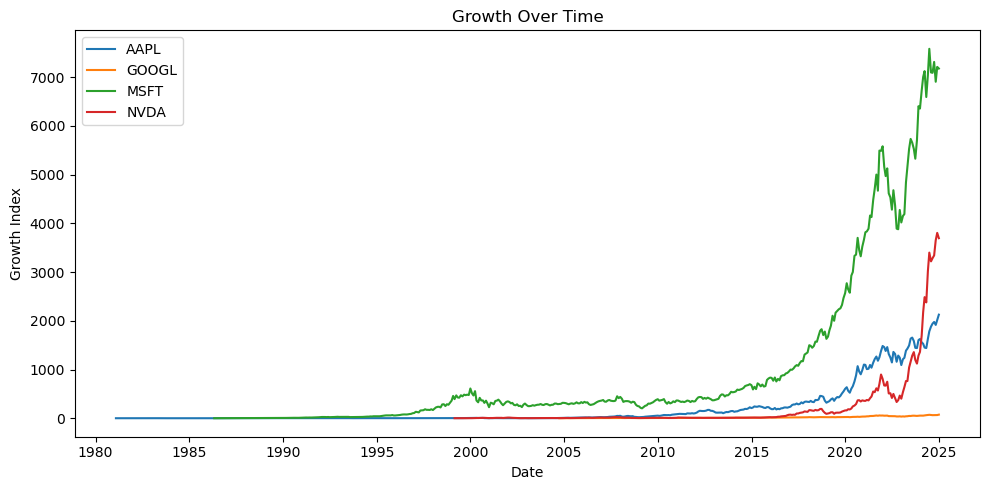

In [20]:
plt.figure(figsize=(10, 5))

for stock in df["htsymbol"].unique():
    temp = df[df["htsymbol"] == stock]
    plt.plot(temp["date"], temp["growth"], label=stock)
    
plt.title("Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Growth Index")
plt.legend()
plt.tight_layout()
plt.show()

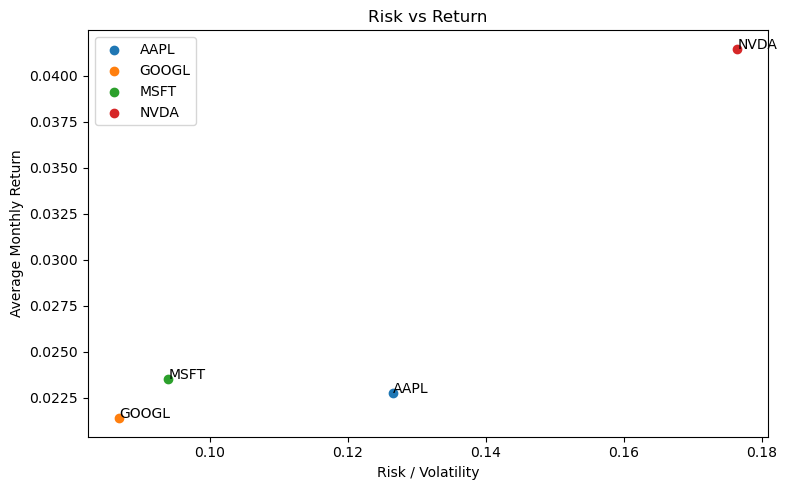

In [22]:
risk_return = df.groupby("htsymbol") ["monthly_return"].agg(["mean", "std"])

plt.figure(figsize=(8, 5))

for stock in risk_return.index:
    plt.scatter(risk_return.loc[stock, "std"], risk_return.loc[stock, "mean"], label=stock)
    plt.text(risk_return.loc[stock, "std"], risk_return.loc[stock, "mean"], stock)
    
plt.title("Risk vs Return")
plt.xlabel("Risk / Volatility")
plt.ylabel("Average Monthly Return")
plt.legend()
plt.tight_layout()
plt.show()

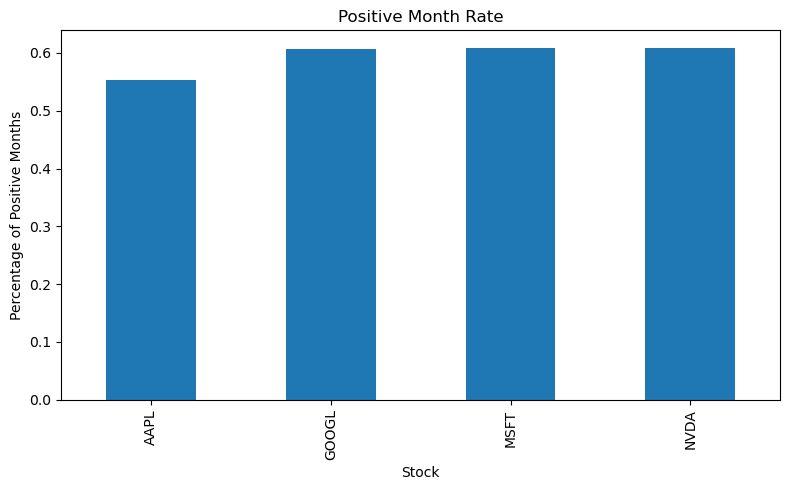

In [24]:
consistency = df.groupby("htsymbol") ["positive_month"].mean()

plt.figure(figsize=(8, 5)) 
consistency.plot(kind="bar")
plt.title("Positive Month Rate")
plt.xlabel("Stock")
plt.ylabel("Percentage of Positive Months")
plt.tight_layout()
plt.show()

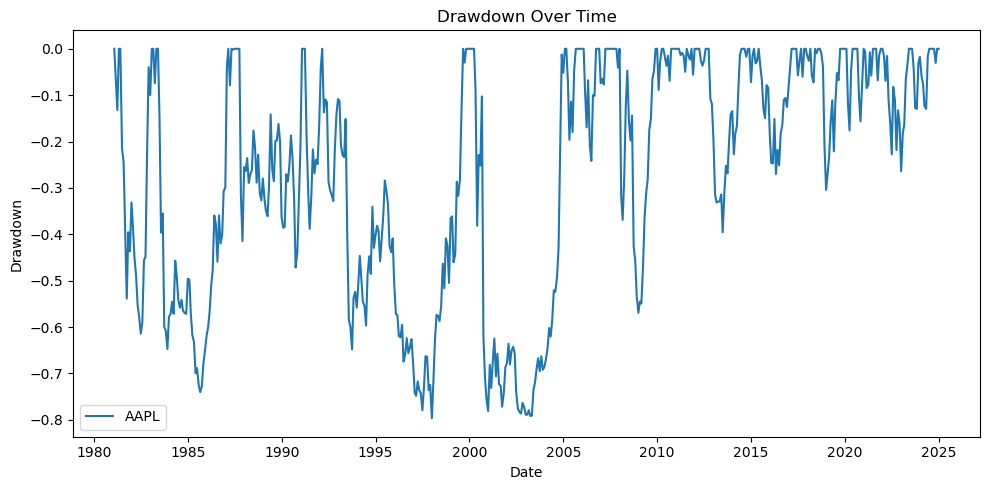

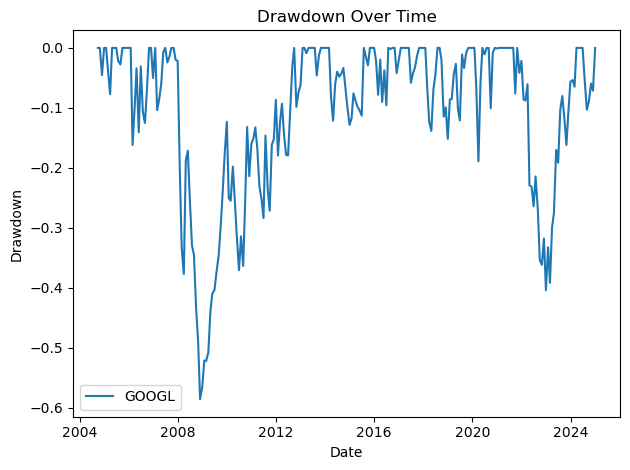

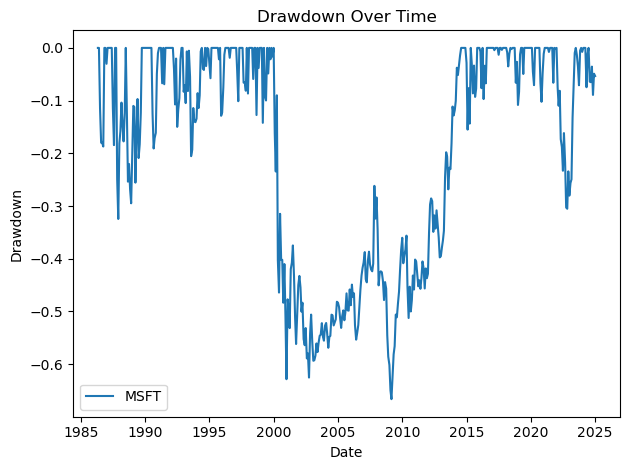

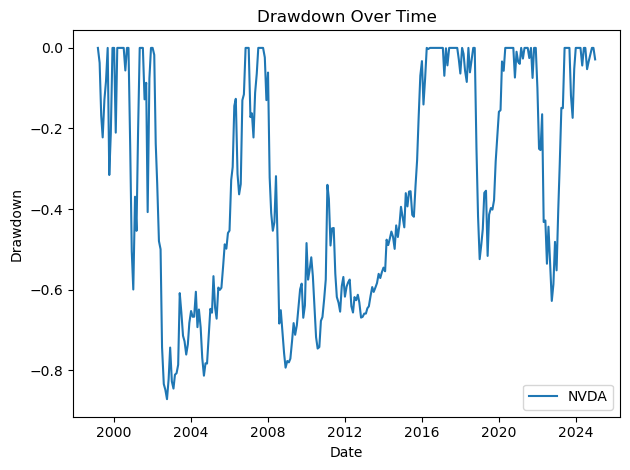

In [25]:
plt.figure(figsize=(10,5))

for stock in df["htsymbol"].unique():
    temp = df[df["htsymbol"] == stock]
    plt.plot(temp["date"],
temp["drawdown"], label=stock)
    
    plt.title("Drawdown Over Time")
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.legend()
    plt.tight_layout()
    plt.show()
    

In [26]:
df.to_csv("tech_stock_alltime.csv", index=False)

In [ ]:
## Key Findings

- Growth shows which stock increased the most ovet ime.
- Risk shows how much the stock fluctuates.
- Consistency shows how often the stock had postivie monthly returns.
- Drawdown shows the downside risk during difficult periods.